In [1]:
from sklearn.datasets import fetch_openml

dataset = fetch_openml(data_id=42803, as_frame=True)

In [2]:
# Print the dataset description
print(dataset["DESCR"])

Data reported to the police about the circumstances of personal injury road accidents in Great Britain from 1979, and the maker and model information of vehicles involved in the respective accident.

This version includes data up to 2015.

Downloaded from openml.org.


In [3]:
df_X = dataset["frame"]

In [6]:
df_X.sample(5)

,Accident_Index,Vehicle_Reference_df_res,Vehicle_Type,Towing_and_Articulation,Vehicle_Manoeuvre,Vehicle_Location-Restricted_Lane,Junction_Location,Skidding_and_Overturning,Hit_Object_in_Carriageway,Vehicle_Leaving_Carriageway,...,Age_Band_of_Casualty,Casualty_Severity,Pedestrian_Location,Pedestrian_Movement,Car_Passenger,Bus_or_Coach_Passenger,Pedestrian_Road_Maintenance_Worker,Casualty_Type,Casualty_Home_Area_Type,Casualty_IMD_Decile
193205,2015320124911,2.0,9.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,...,6.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,4.0
348631,2015950001520,2.0,9.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,5.0,3.0,0.0,0.0,0.0,0.0,0.0,9.0,1.0,NaN
319196,2015530210232,2.0,1.0,0.0,18.0,0.0,0.0,0.0,0.0,0.0,...,8.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,NaN
284817,2015460263078,4.0,9.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,...,6.0,3.0,0.0,0.0,1.0,0.0,0.0,9.0,1.0,1.0
359774,201597NE04810,2.0,8.0,0.0,18.0,0.0,8.0,0.0,0.0,1.0,...,8.0,3.0,0.0,0.0,2.0,0.0,0.0,8.0,1.0,NaN


In [7]:
# Show shape of the dataset
df_X.shape

(363243, 67)

In [28]:
import pandas as pd

# Count how many times each data type is present in the dataset
df_X.dtypes.value_counts()
df_X.dtypes.unique()

array([dtype('O'), dtype('float64'), dtype('<M8[ns]')], dtype=object)

In [13]:
# Display non-numerical features
df_X.select_dtypes(exclude="number").head()

,Accident_Index,Sex_of_Driver,Date,Time,Local_Authority_(Highway),LSOA_of_Accident_Location
0,201501BS70001,1.0,12/01/2015,18:45,E09000020,E01002825
1,201501BS70002,1.0,12/01/2015,07:50,E09000020,E01002820
2,201501BS70004,1.0,12/01/2015,18:08,E09000020,E01002833
3,201501BS70005,1.0,13/01/2015,07:40,E09000020,E01002874
4,201501BS70008,1.0,09/01/2015,07:30,E09000020,E01002814


In [17]:
df_X["Sex_of_Driver"] = df_X["Sex_of_Driver"].astype("float")

In [18]:
# Let's combine 'Date' and 'Time' into 'Timestamp'
df_X["Timestamp"] = pd.to_datetime(df_X["Date"] + " " + df_X["Time"])

In [20]:
df_X = df_X.drop(labels=["Date", "Time"], axis=1)


KeyError: "['Date' 'Time'] not found in axis"

In [22]:
# Let's show content of 'Timestamp'
df_X["Timestamp"].sample(5)


313689   2015-04-06 22:40:00
87334    2015-04-24 16:01:00
184230   2015-02-14 21:10:00
103207   2015-08-07 07:50:00
256345                   NaT
Name: Timestamp, dtype: datetime64[ns]

In [23]:
df_X["day_of_week"] = df_X["Timestamp"].dt.day_of_week
df_X["hour_of_day"] = df_X["Timestamp"].dt.hour

In [24]:
unique_values = df_X.select_dtypes(include="number").nunique().sort_values()

In [33]:
df_X.select_dtypes(include="number").nunique()

Vehicle_Reference_df_res            37
Vehicle_Type                        20
Towing_and_Articulation              6
Vehicle_Manoeuvre                   18
Vehicle_Location-Restricted_Lane    10
                                    ..
Casualty_Type                       21
Casualty_Home_Area_Type              3
Casualty_IMD_Decile                 10
day_of_week                          7
hour_of_day                         24
Length: 64, dtype: int64

/home/ruop/.local/share/mamba/envs/adsml/lib/python3.9/site-packages/pandas/plotting/_core.py:1746: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


<AxesSubplot:>

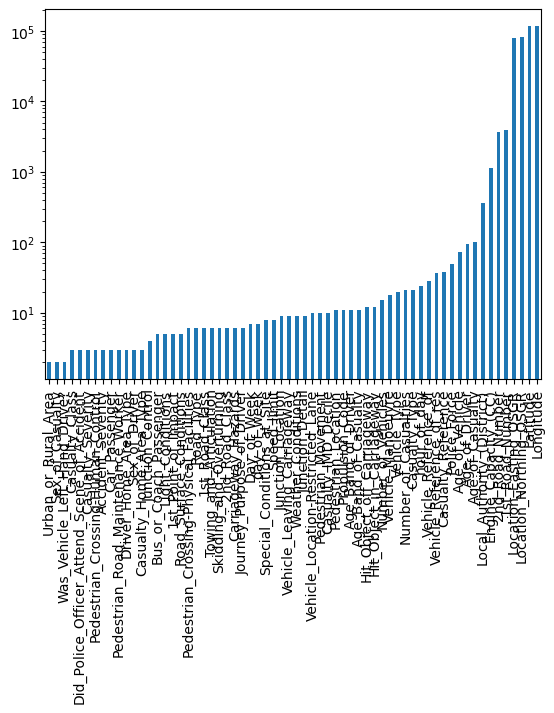

In [35]:
unique_values.plot.bar(logy=True)

In [37]:
# duplicates

df_X.duplicated().sum()

0

In [38]:
df_X.drop(labels=["Accident_Index"], axis=1).duplicated().sum()

22

In [39]:
is_duplicate = df_X.drop(labels=["Accident_Index"], axis=1).duplicated(keep=False)

In [40]:
df_X[is_duplicate].head(5)

,Accident_Index,Vehicle_Reference_df_res,Vehicle_Type,Towing_and_Articulation,Vehicle_Manoeuvre,Vehicle_Location-Restricted_Lane,Junction_Location,Skidding_and_Overturning,Hit_Object_in_Carriageway,Vehicle_Leaving_Carriageway,...,Pedestrian_Movement,Car_Passenger,Bus_or_Coach_Passenger,Pedestrian_Road_Maintenance_Worker,Casualty_Type,Casualty_Home_Area_Type,Casualty_IMD_Decile,Timestamp,day_of_week,hour_of_day
109183,2015132190930,1.0,9.0,0.0,18.0,0.0,6.0,0.0,0.0,0.0,...,0.0,2.0,0.0,0.0,9.0,NaN,NaN,2015-09-01 15:39:00,1.0,15.0
109184,2015132190930,2.0,9.0,0.0,18.0,0.0,1.0,0.0,0.0,1.0,...,0.0,2.0,0.0,0.0,9.0,NaN,NaN,2015-09-01 15:39:00,1.0,15.0
109201,2015132191539,1.0,9.0,0.0,18.0,0.0,6.0,0.0,0.0,0.0,...,0.0,2.0,0.0,0.0,9.0,NaN,NaN,2015-09-01 15:39:00,1.0,15.0
109202,2015132191539,2.0,9.0,0.0,18.0,0.0,1.0,0.0,0.0,1.0,...,0.0,2.0,0.0,0.0,9.0,NaN,NaN,2015-09-01 15:39:00,1.0,15.0
151844,201520S038475,1.0,9.0,0.0,18.0,0.0,8.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,9.0,1.0,2.0,2015-05-30 16:12:00,5.0,16.0


In [41]:
#  Extract column names of all features, except 'Accident_Index'
columns_to_consider = df_X.drop(labels=["Accident_Index"], axis=1).columns


# Drop duplicates based on 'columns_to_consider'
df_X = df_X.drop_duplicates(subset=columns_to_consider)
df_X.shape

(363221, 68)

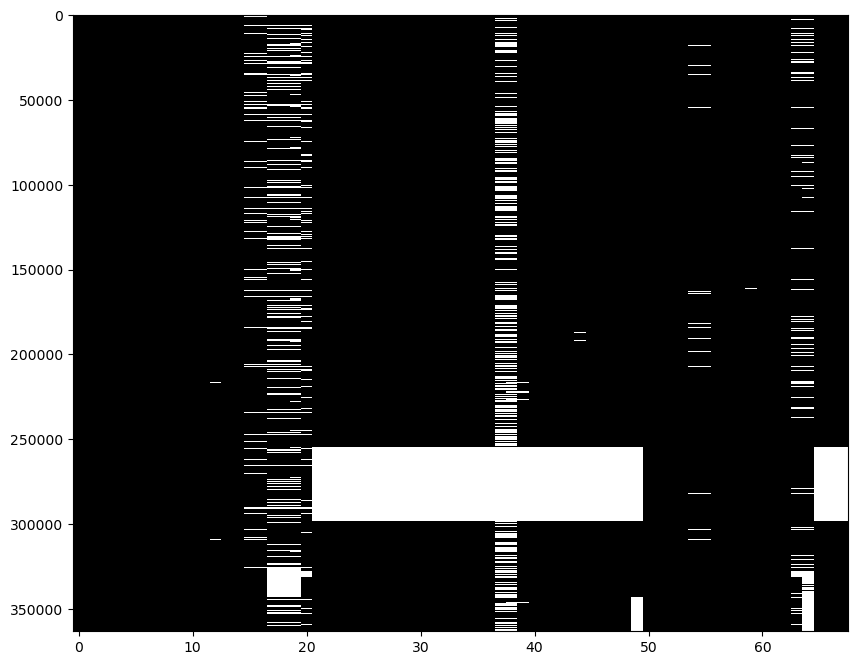

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.imshow(df_X.isna(), aspect="auto", interpolation="nearest", cmap="gray");

In [43]:
df_X = df_X.dropna(thresh=df_X.shape[1] * 0.75, axis=0)
df_X.shape

(319847, 68)

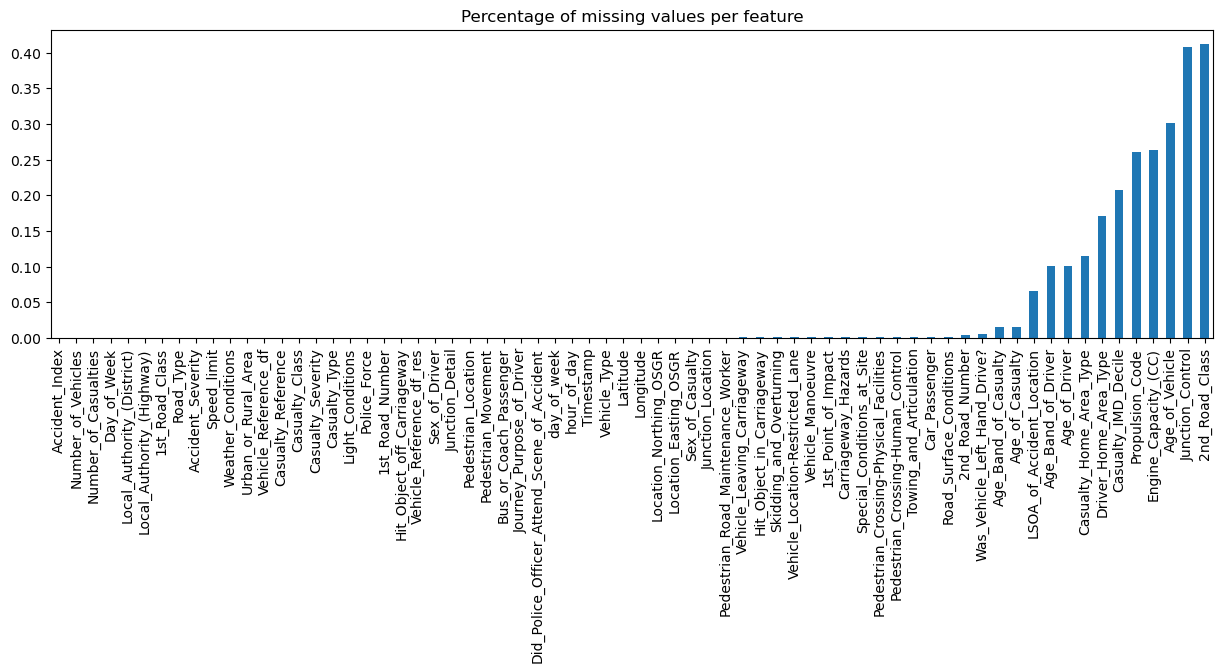

In [44]:
df_X.isna().mean().sort_values().plot(
    kind="bar", figsize=(15, 4), title="Percentage of missing values per feature");

<AxesSubplot:>

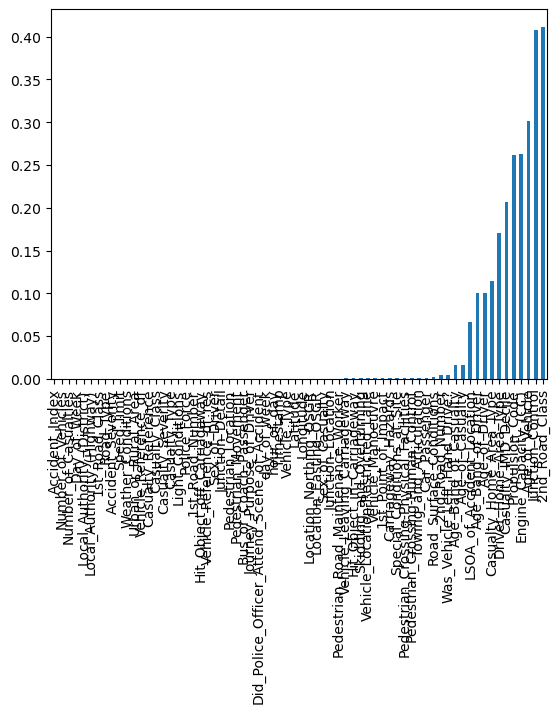

In [50]:
df_X.isna().mean().sort_values().plot.bar()

In [51]:
df_X = df_X.dropna(thresh=df_X.shape[0] * 0.85, axis=1)
df_X.shape

(319847, 61)

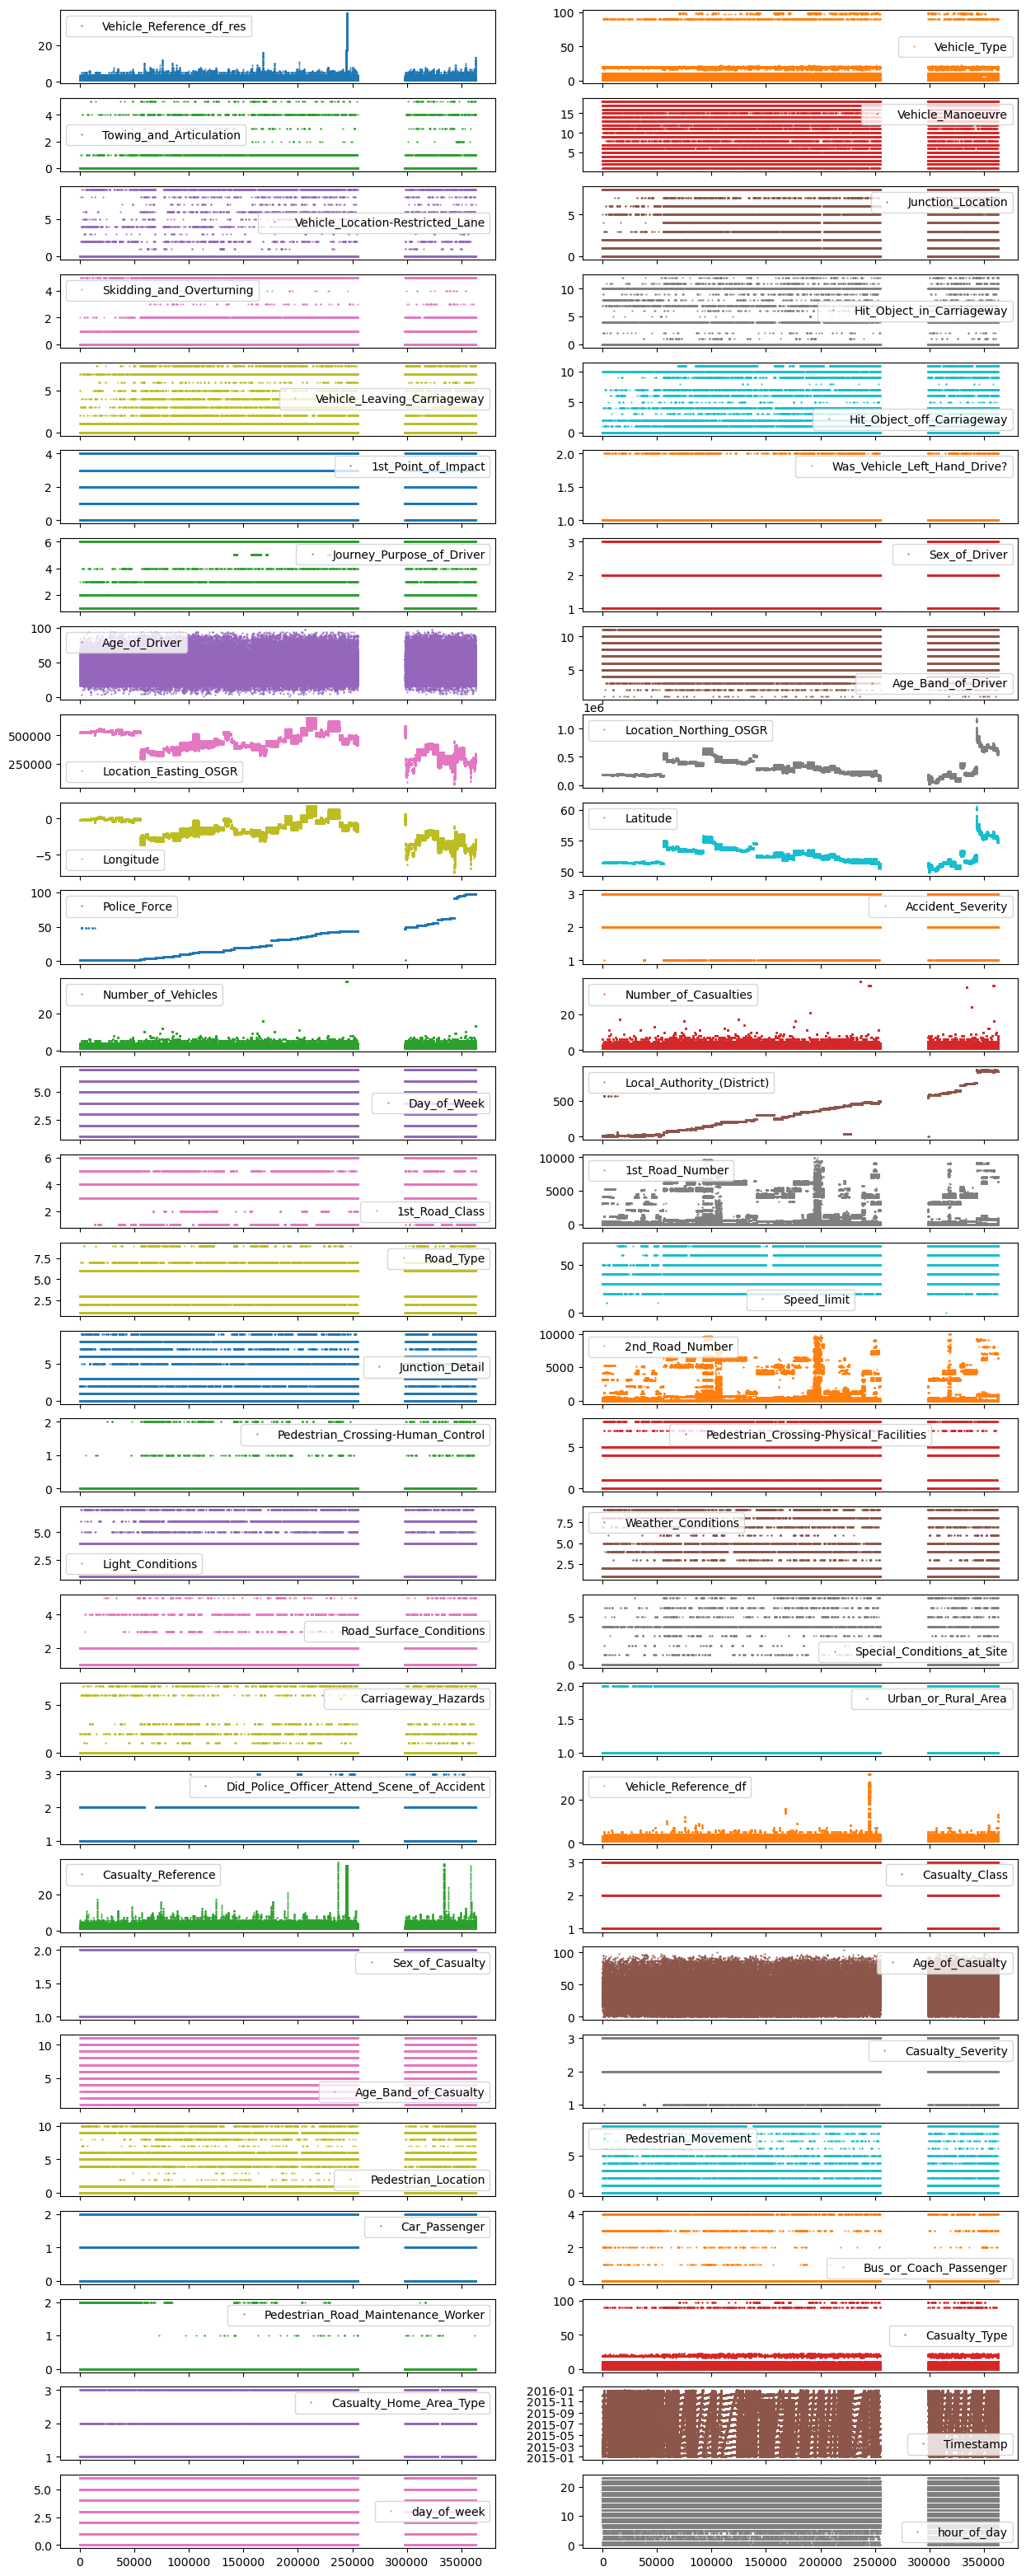

In [52]:
df_X.plot(lw=0, marker=".", subplots=True, layout=(-1, 2), figsize=(15, 40), markersize=1);

In [53]:
df_X = df_X.reset_index(drop=True)

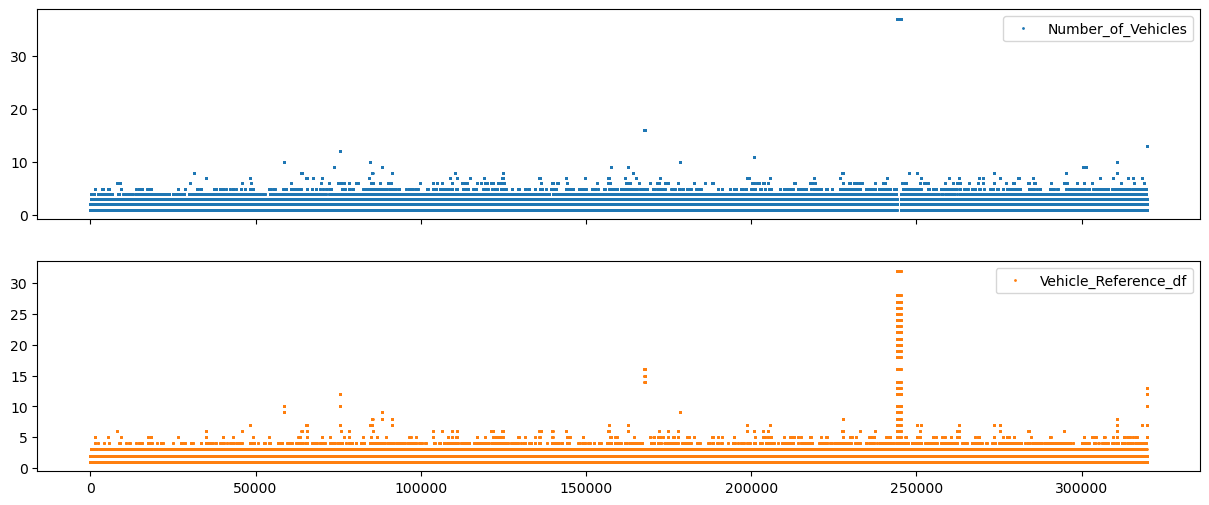

In [54]:
df_X[["Number_of_Vehicles", "Vehicle_Reference_df"]].plot(
    lw=0, marker=".", subplots=True, figsize=(15, 6), markersize=2);

In [55]:
# Let's create a mask which has 'True' for every sample that needs to be dropped
entries_to_drop = df_X["Number_of_Vehicles"].gt(30)
print(entries_to_drop.sum())

1332


In [56]:

# Dropping these entries by only selecting the samples that shouldn't be dropped
df_X = df_X[~entries_to_drop]

In [57]:
# Identify non-numerical features
df_non_numerical = df_X.select_dtypes(exclude=["number", "datetime"])
df_non_numerical.head()

,Accident_Index,Local_Authority_(Highway),LSOA_of_Accident_Location
0,201501BS70001,E09000020,E01002825
1,201501BS70002,E09000020,E01002820
2,201501BS70004,E09000020,E01002833
3,201501BS70005,E09000020,E01002874
4,201501BS70008,E09000020,E01002814


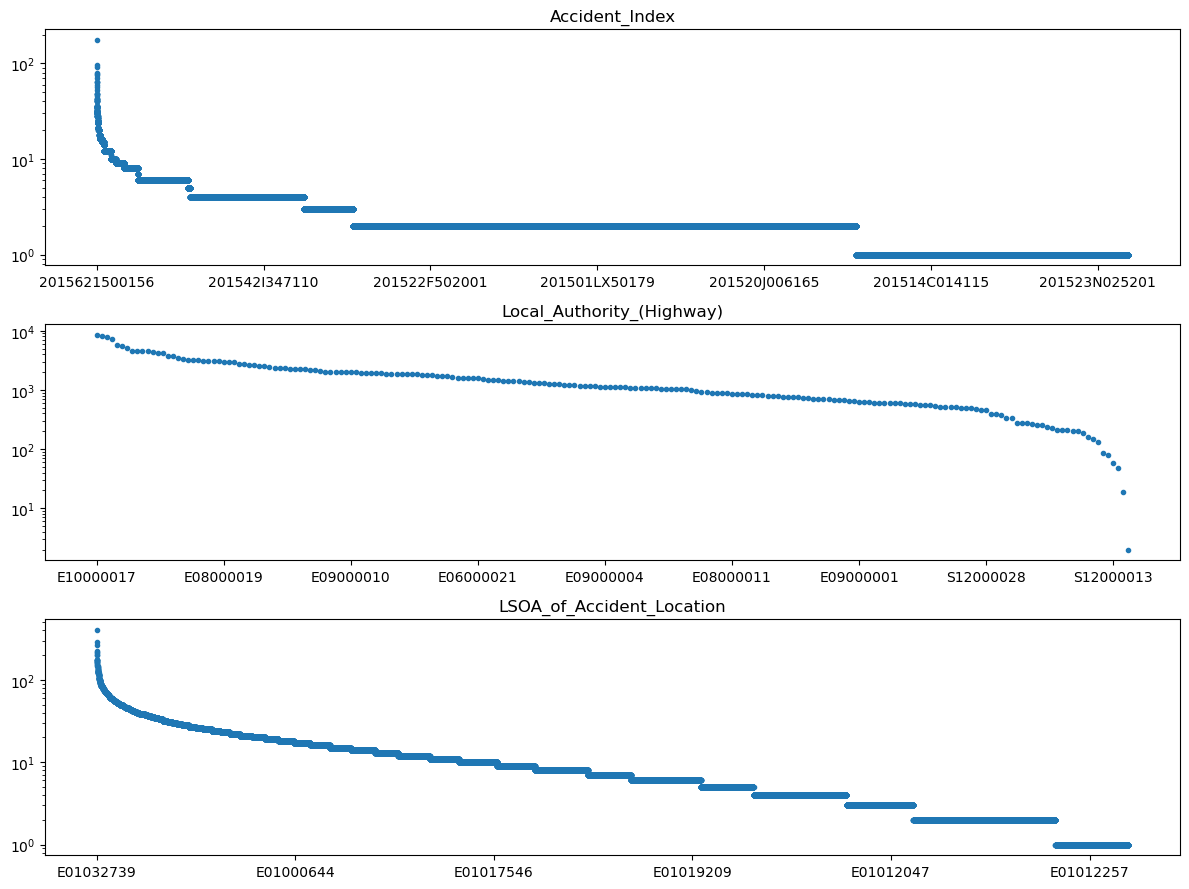

In [58]:
# Create figure object with 3 subplots
fig, axes = plt.subplots(ncols=1, nrows=3, figsize=(12, 9))

# Loop through features and put each subplot on a matplotlib axis object
for col, ax in zip(df_non_numerical.columns, axes.ravel()):

    # Selects one single feature and counts number of occurrences per unique value
    df_non_numerical[col].value_counts().plot(

        # Plots this information in a figure with log-scaled y-axis
        logy=True, title=col, lw=0, marker=".", ax=ax)
    
plt.tight_layout()


In [65]:
accident_ids = df_non_numerical["Accident_Index"].value_counts().head(10).index

In [66]:
# Removes accidents from the 'accident_ids' list
df_X = df_X[~df_X["Accident_Index"].isin(accident_ids)]
df_X.shape


(317659, 61)